# 05 · The selected model — is its solution unique, and what does it say?

*Task 05. Tasks 00–04 fixed the model: how it is trained, how wide it is, what is
connected, and how much passes between regions. This asks the question the whole rebuild
exists to answer, and then reads the circuit that survives it.*

The chapter's original problem was that independently fitted networks reproduced the data
equally well and disagreed about the currents flowing between regions. Everything since
has been an attempt to remove the reasons for that disagreement that are *not* about the
brain: an optimiser that diverged, an objective that under-weighted one fixation type, a
network with more freedom than the data can pin down. What is left is the question itself.

**Two things had to be fixed before it could be asked properly.**

*Agreement needs a floor.* A number like "0.6 agreement between seeds" means nothing on
its own. Most of these measures are already high between networks that were **never
trained at all**, because a block-structured matrix rescaled to a fixed spectral radius has
a constrained spectrum before it sees any data. Every measure here is therefore reported
against an architectural null — the same measure between untrained models of the same
architecture, replayed on the same inputs and initial states.

*Agreement has to respect the model's symmetry.* For a tanh network with a linear readout,
relabelling hidden units by a permutation $P$ and flipping their signs with a diagonal
$S\in\{\pm1\}$ leaves every output identical, because $\tanh$ is odd:

$$W_{rec}\mapsto PS\,W_{rec}\,(PS)^{\top},\qquad W_{in}\mapsto PS\,W_{in},\qquad
W_{out}\mapsto W_{out}(PS)^{\top}.$$

The signed permutation group is the *only* exact symmetry — the nonlinearity blocks general
rotations — so it is exactly the licence a comparison has. Measures invariant to more than
it (CKA, RSA) can only overstate agreement, so they are reported below the stricter ones
rather than instead of them.

| Section | |
|---|---|
| 1 | The model under test |
| 2 | Run state and submission (off by default) |
| 3 | Does the ensemble fit? |
| 4 | Invariants against the architectural null — the gate |
| 5 | The stronger floor: fits to structureless data |
| 6 | Inter-regional communication: direction, not just magnitude |
| 7 | Three fixation types, one autonomous system |
| 8 | What each pathway was carrying |
| 9 | Reading the result |

**Nothing here submits a job unless a `SUBMIT_*` flag is set to `True`.**

In [1]:
# The analysis code these notebooks call lives in src/ and is edited between runs. Without
# autoreload a kernel keeps whatever it imported first, so a function added to src after
# the kernel started raises AttributeError until it is restarted -- which is easy to
# misread as a bug in the code rather than in the kernel's cache.
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_circuit as circ
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_protocol as protocol
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_sweep as sweep
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.analysis import fixation_psth_noise_ceiling as ceiling_mod
from dal_monte_2022_analysis.ephys.modeling.fixation_mrnn_analysis import replay_fixation_mrnn_run
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_circuit as cviz
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_sweep as viz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings,
    apply_thesis_plot_style,
    figure_to_png_bytes,
    save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
MRNN_CFG_PATH = repo_root / "configs" / "ephys_fixation_mrnn.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))

PROTOCOL_ROOT = protocol.resolve_chapter_root(DATASET_CFG_PATH, task="00_training_protocol")
MODEL_SELECTION_ROOT = sweep.resolve_task_root("02_model_selection", DATASET_CFG_PATH)
BOTTLENECK_ROOT = sweep.resolve_task_root("03_bottleneck_rank", DATASET_CFG_PATH)
TASK_ROOT = sweep.resolve_task_root("05_ensemble_and_circuit", DATASET_CFG_PATH)
CEILING_DIR = ceiling_mod.resolve_output_dir(DATASET_CFG_PATH)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="05_ensemble_and_circuit")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

SELECTED_PROTOCOL, PROTOCOL_IS_PROVISIONAL = sweep.load_selected_protocol_or_provisional(
    PROTOCOL_ROOT / "selected_protocol.yaml"
)

#: A small ensemble first, on purpose. A hundred seeds of a model whose solution is not
#: unique is a hundred copies of the same non-result, and the cost of finding that out at
#: N=100 is a day of cluster time. Section 4 is the gate: it decides whether scaling up
#: measures anything.
ENSEMBLE_SEEDS = 5
#: Seeds for each surrogate-target arm in Section 5. Fewer, because that arm only has to
#: establish a floor, not resolve it precisely.
NULL_SEEDS = 3
#: Draws for the free architectural null. No fitting is involved, so this is cheap.
ARCHITECTURE_DRAWS = 5
BIN_SIZE_S = 0.01


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))


print("task root :", TASK_ROOT)

task root : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/chapter/05_ensemble_and_circuit


## 1. The model under test

Task 04 writes its choice to `selected_constrained_model.yaml`: the corner of the three
constraint families that still reproduced the data, verified jointly rather than inferred
from the coordinate-wise sweeps. That file is the input here.

That file appears in two states, and the difference matters:

- **unverified** — task 04 has found the corner where the three constraint families meet,
  from the coordinate-wise sweeps, but has not yet fitted it. The corner is written as soon
  as it is defined precisely so this notebook can queue its ensemble in parallel rather
  than waiting out another round trip on the cluster.
- **verified** — task 04 has fitted the corner and confirmed it still reaches the ceiling.
  If it does not, the constraints interact and the corner is wrong; this notebook says so
  rather than silently measuring identifiability on a model that does not fit.

Running on the unverified corner is a reasonable bet — the coordinate-wise sweeps have to
be badly wrong for it to fail — but it is a bet, so it is behind a flag.

If no corner exists at all, the notebook falls back to task 02's unconstrained base model
and says so. That fallback is not a substitute: the entire hypothesis behind the
constraints is that they *narrow the solution set*, so identifiability measured on the
unconstrained model is the **baseline** for that claim rather than a test of it. It is
still worth fitting for exactly that reason, which is why the flag allows it.

In [2]:
CONSTRAINED_PATH = BOTTLENECK_ROOT / "selected_constrained_model.yaml"
BASE_MODEL_PATH = MODEL_SELECTION_ROOT / "selected_base_model.yaml"

if CONSTRAINED_PATH.exists():
    SELECTION = yaml.safe_load(CONSTRAINED_PATH.read_text())
    SELECTION_IS_VERIFIED = bool(SELECTION.get("verified", False))
    SELECTION_IS_CONSTRAINED = True
    SOURCE = (f"task 04 (`{CONSTRAINED_PATH.name}`, "
              f"{'verified' if SELECTION_IS_VERIFIED else '**not yet verified jointly**'})")
elif BASE_MODEL_PATH.exists():
    SELECTION = yaml.safe_load(BASE_MODEL_PATH.read_text())
    SELECTION_IS_VERIFIED = False
    SELECTION_IS_CONSTRAINED = False
    SOURCE = "task 02 base model — **task 04 has not defined a corner**"
else:
    SELECTION = None
    SELECTION_IS_VERIFIED = False
    SELECTION_IS_CONSTRAINED = False
    SOURCE = "**nothing upstream has been selected**"

#: Set True to fit the ensemble on a corner task 04 has defined but not yet fitted, or on
#: the unconstrained base model when no corner exists. Both are useful and neither is the
#: finished article: the unverified corner is a bet on the coordinate-wise sweeps, and the
#: unconstrained model is the baseline the constraints are supposed to improve on.
ALLOW_UNVERIFIED_SELECTION = False

STRUCTURAL_KEYS = ("hidden_units", "condition_loss_weighting", "l1_weight_scale",
                   "recurrent_bottleneck_dim", "within_region_density", "cross_region_density",
                   "recurrent_connectivity")
if SELECTION is None:
    model_overrides = {}
    display(Markdown(
        f"🔴 **No upstream selection exists.** Neither `{CONSTRAINED_PATH}` nor "
        f"`{BASE_MODEL_PATH}` is present.\n\n"
        f"To produce the first: run task 04 through Section 10, which writes the corner as soon "
        f"as the three prong knees are known — Sections 9 and 10 both have to be executed, and "
        f"Section 9 needs its sparsity arm trained."
    ))
else:
    model_overrides = {key: SELECTION[key] for key in STRUCTURAL_KEYS if key in SELECTION}
    display(Markdown(f"Model under test, from {SOURCE}:"))
    display(pd.DataFrame([model_overrides]))
    if not SELECTION_IS_CONSTRAINED:
        display(Markdown(
            "⚠️ **This is the unconstrained model**, because task 04 has not defined a corner. "
            "The chapter's hypothesis is that the constraints narrow the solution set, so "
            "identifiability measured here is the *baseline* for that claim rather than a test "
            "of it — worth fitting, but not the model this task is about. Re-run task 04 "
            "Sections 9 and 10 to define the corner, or set "
            "`ALLOW_UNVERIFIED_SELECTION = True` to fit the baseline now."
        ))
    elif not SELECTION_IS_VERIFIED:
        display(Markdown(
            f"⚠️ **The corner has not been verified jointly.** Task 04 found it by varying each "
            f"constraint family on its own; whether all of them together still reach the ceiling "
            f"is what its Section 10 fits. Its coordinate-wise prediction is "
            f"**{SELECTION.get('coordinate_wise_prediction', float('nan')):.4f}**.\n\n"
            f"Queueing the ensemble now is reasonable — both notebooks would fit the same "
            f"configuration, and the constraints would have to interact badly for it to fail — "
            f"but it is a bet, so set `ALLOW_UNVERIFIED_SELECTION = True` to take it. If the "
            f"joint fit later comes out inadequate, everything below is measuring a model that "
            f"does not reproduce the data."
        ))

variants = [sweep.ModelVariant(label="ensemble", arm="fitted", overrides=model_overrides)]
# The two surrogates fail differently and are meant to be read together. Phase
# randomization keeps each channel's power spectrum and destroys the waveform, so anything
# surviving it comes from the architecture. Time shuffling keeps the instantaneous
# population covariance exactly and destroys only the order in which states are visited,
# so anything surviving it comes from the geometry rather than from the dynamics.
null_variants = [
    sweep.ModelVariant(label=f"null_{mode}", arm="surrogate target",
                       overrides={**model_overrides, "target_surrogate": mode})
    for mode in ("phase_randomized", "time_shuffled")
]
seeds = protocol.protocol_seeds(n_seeds=ENSEMBLE_SEEDS)
null_seed_list = seeds[:NULL_SEEDS]
display(Markdown(
    f"**{ENSEMBLE_SEEDS} seeds** of the selected model, plus **{len(null_variants)} surrogate "
    f"arms × {NULL_SEEDS} seeds = {len(null_variants) * NULL_SEEDS}** runs for the stronger floor."
))

Model under test, from task 04 (`selected_constrained_model.yaml`, **not yet verified jointly**):

,hidden_units,condition_loss_weighting,l1_weight_scale,recurrent_bottleneck_dim,within_region_density,cross_region_density
0,40,balanced,0.0,None,0.05,0.25


⚠️ **The corner has not been verified jointly.** Task 04 found it by varying each constraint family on its own; whether all of them together still reach the ceiling is what its Section 10 fits. Its coordinate-wise prediction is **1.0001**.

Queueing the ensemble now is reasonable — both notebooks would fit the same configuration, and the constraints would have to interact badly for it to fail — but it is a bet, so set `ALLOW_UNVERIFIED_SELECTION = True` to take it. If the joint fit later comes out inadequate, everything below is measuring a model that does not reproduce the data.

**5 seeds** of the selected model, plus **2 surrogate arms × 3 seeds = 6** runs for the stronger floor.

## 2. Run state and submission

Same discipline as the earlier tasks: cells a live array already owns are skipped, so this
is safe to re-run while jobs are on the queue, and nothing is submitted unless the flag is
set.

Every member of a surrogate arm is fitted to the **same** surrogate target. That detail is
what makes the arm a null at all: if each seed saw a differently randomized target, the
seeds would disagree simply because they were shown different data, and the floor would be
measuring the randomization rather than the model.

In [3]:
SUBMIT = False        # <-- set to True to submit the fitted ensemble
SUBMIT_NULL = False   # <-- set to True to submit the surrogate-target arms

JOBS_DIRS = [TASK_ROOT / "_jobs", TASK_ROOT / "_jobs_null"]
flight = sweep.in_flight_run_dirs(*JOBS_DIRS)
blocked = SELECTION is None or (not SELECTION_IS_VERIFIED and not ALLOW_UNVERIFIED_SELECTION)


def plan(variant_list, seed_list):
    commands, _ = sweep.variant_job_commands(
        variant_list, seed_list, root=TASK_ROOT, repo_root=repo_root,
        protocol=SELECTED_PROTOCOL, mrnn_cfg_path=MRNN_CFG_PATH,
        exclude_run_dirs=flight["run_dirs"],
    )
    inventory = sweep.index_variant_runs(
        TASK_ROOT, variant_list, seed_list, in_flight=flight["run_dirs"]
    )
    return commands, inventory


def submit(commands, jobs_dir, name):
    from datetime import datetime

    from dal_monte_2022_analysis.runtime.hpc.jobs import submit_dsq_array_job, write_job_file

    jobs_dir.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    job_file = jobs_dir / f"{name}_{stamp}.txt"
    write_job_file(job_file, commands)
    run_dirs = [Path(line.split("--run-dir ")[1].split()[0]) for line in commands]
    job_id = submit_dsq_array_job(
        job_file_path=job_file, sbatch_script_path=jobs_dir / f"{name}_{stamp}.sh",
        log_dir=jobs_dir / "logs", job_name=f"mrnn_{name}", partition="psych_gpu",
        cpus_per_task=1, mem_per_cpu="12G", time_limit="06:00:00", gres="gpu:1",
    )
    sweep.record_submission(jobs_dir, job_id=job_id, run_dirs=run_dirs, label=f"{name} {stamp}")
    (jobs_dir / "job_id.txt").write_text(str(job_id) + "\n")
    return job_id


commands, inventory = plan(variants, seeds) if model_overrides else ([], pd.DataFrame())
null_commands, null_inventory = (plan(null_variants, null_seed_list) if model_overrides
                                 else ([], pd.DataFrame()))

for name, frame in (("fitted ensemble", inventory), ("surrogate arms", null_inventory)):
    if len(frame):
        display(Markdown(
            f"**{name}:** {int(frame['complete'].sum())} complete, "
            f"{int(frame['queued'].sum())} on the queue, {int(frame['diverged'].sum())} diverged, "
            f"{int(frame['pending'].sum())} unqueued of {len(frame)} cells."
        ))
display(Markdown(sweep.describe_in_flight(flight)))

if blocked and (commands or null_commands):
    display(Markdown(
        "**Not submitted**: "
        + ("no upstream selection exists — see Section 1 for which task 04 sections to run."
           if SELECTION is None else
           f"the model under test is {'an unverified corner' if SELECTION_IS_CONSTRAINED else 'the unconstrained baseline'}. "
           f"Set `ALLOW_UNVERIFIED_SELECTION = True` to queue on it anyway.")
    ))
else:
    if SUBMIT and commands:
        display(Markdown(f"Submitted **{len(commands)}** runs as array "
                         f"**{submit(commands, TASK_ROOT / '_jobs', 'ensemble')}**."))
    elif commands:
        display(Markdown(f"`SUBMIT` is **False** — {len(commands)} ensemble run(s) not submitted."))
    if SUBMIT_NULL and null_commands:
        display(Markdown(f"Submitted **{len(null_commands)}** null runs as array "
                         f"**{submit(null_commands, TASK_ROOT / '_jobs_null', 'null')}**."))
    elif null_commands:
        display(Markdown(f"`SUBMIT_NULL` is **False** — {len(null_commands)} null run(s) not submitted."))

**fitted ensemble:** 5 complete, 0 on the queue, 0 diverged, 0 unqueued of 5 cells.

**surrogate arms:** 6 complete, 0 on the queue, 0 diverged, 0 unqueued of 6 cells.

No array from this task is on the queue.

## 3. Does the ensemble fit?

Consistency is only interesting among models that reproduce the data. A collection of
badly-fitted networks can agree perfectly and the agreement means nothing, so the fit comes
first — and the loss trajectories come before the fit, because a constraint that merely
makes the problem harder to optimise and one the data cannot tolerate look identical in the
final loss.

,label,n_seeds,n_converged,worst_late_spikes,worst_final_over_best,median_best_loss,best_loss_spread
0,ensemble,5,5,0,1.0,0.000563,1.747088


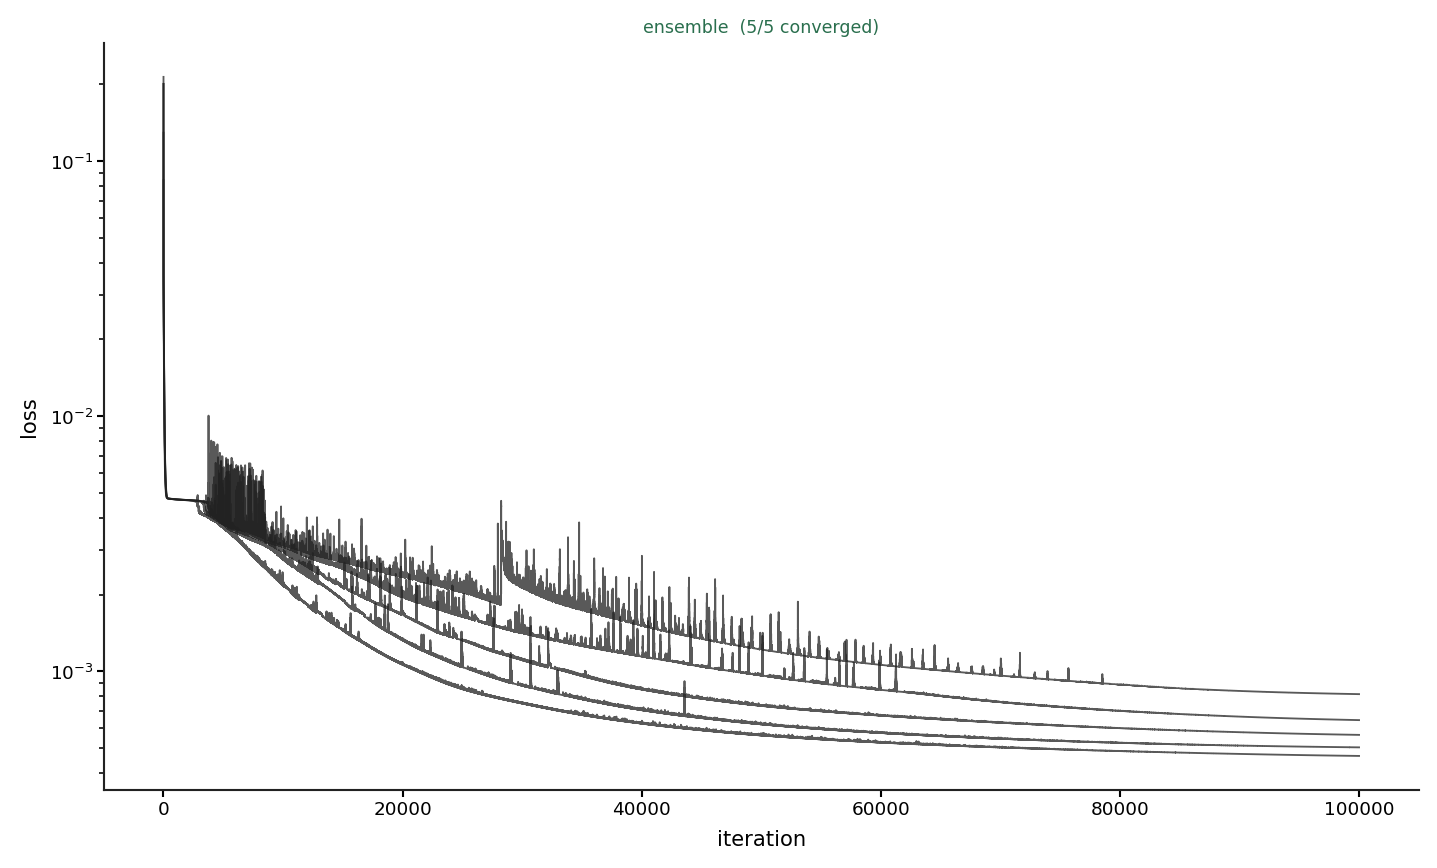

**Fit against the noise ceiling**, by condition:

,mean,std,min
condition,,,
face_interactive,0.9928,0.0139,0.9615
face_non_interactive,0.9567,0.0269,0.9028
object,0.9607,0.0187,0.9205


,label,worst_condition,seed_spread,mean_all,ceiling_margin,cost_vs_baseline,tolerance,adequate
0,ensemble,0.9553,0.019,0.9701,-0.0447,0.0,0.038,False


Seed-to-seed spread on the worst condition is **0.0190**. That is the scale against which every agreement number below has to be read: differences between seeds smaller than this are not differences in solution, they are differences in where the optimiser stopped.

In [4]:
histories = sweep.load_histories(inventory) if len(inventory) else {}
ceiling_by_region = (pd.read_csv(CEILING_DIR / "pc_space_ceiling.csv")
                     .groupby("region")["reliability"].mean().to_dict())

if not histories:
    display(Markdown("No ensemble runs have finished yet."))
else:
    convergence = sweep.convergence_table(histories)
    display(convergence.round(6))
    show(viz.plot_sweep_loss_trajectories(histories, convergence=convergence),
         "fig01_ensemble_losses")
    fit = sweep.score_variant_fit(inventory, ceiling_by_region)
    display(Markdown("**Fit against the noise ceiling**, by condition:"))
    display(fit.groupby(["condition"])["r2_vs_ceiling"].agg(["mean", "std", "min"]).round(4))
    adequacy = sweep.adequacy_table(fit, baseline_label="ensemble")
    display(adequacy.round(4))
    display(Markdown(
        f"Seed-to-seed spread on the worst condition is "
        f"**{float(adequacy['seed_spread'].iloc[0]):.4f}**. That is the scale against which every "
        f"agreement number below has to be read: differences between seeds smaller than this are "
        f"not differences in solution, they are differences in where the optimiser stopped."
    ))

## 4. Invariants against the architectural null — the gate

Four measures, ordered from strictest to most permissive. Each is invariant to at least the
signed permutation the model is free to choose, so a low value means the fits genuinely
differ rather than that their units are numbered differently.

| measure | invariant to | what a high value would mean |
|---|---|---|
| matched weight correlation | signed permutation — the exact model symmetry | the same circuit, connection by connection |
| eigenspectrum | any similarity transform | the same linearized dynamics |
| state Procrustes | orthogonal transform | the same trajectory, up to one shared rotation |
| state CKA | orthogonal transform **and** isotropic scaling | the same representational geometry |

Each is plotted against the **architectural null**: the same measure between models of this
architecture that were never trained, replayed on the same inputs and initial states. That
null is not a formality. A block-structured matrix rescaled to a fixed spectral radius has
a constrained spectrum before it sees any data, and the matched-weight measure searches
over $n!\,2^n$ signed permutations for the best alignment, so it will find *something* in
any pair of matrices.

**Read the margin, not the level.** A measure sitting at 0.97 whose null is also at 0.97 is
reporting the architecture, not the data.

,measure,fitted_mean,fitted_sd,null_mean,null_sd,margin,margin_in_null_sd
0,matched weight correlation,0.0002,0.0077,0.0039,0.0172,-0.0037,-0.2147
1,eigenspectrum,0.9215,0.0211,0.9514,0.0284,-0.0300,-1.0535
2,state Procrustes,0.6962,0.1212,0.8916,0.0332,-0.1954,-5.8915
3,state CKA,0.7354,0.1100,0.8658,0.0626,-0.1304,-2.0852


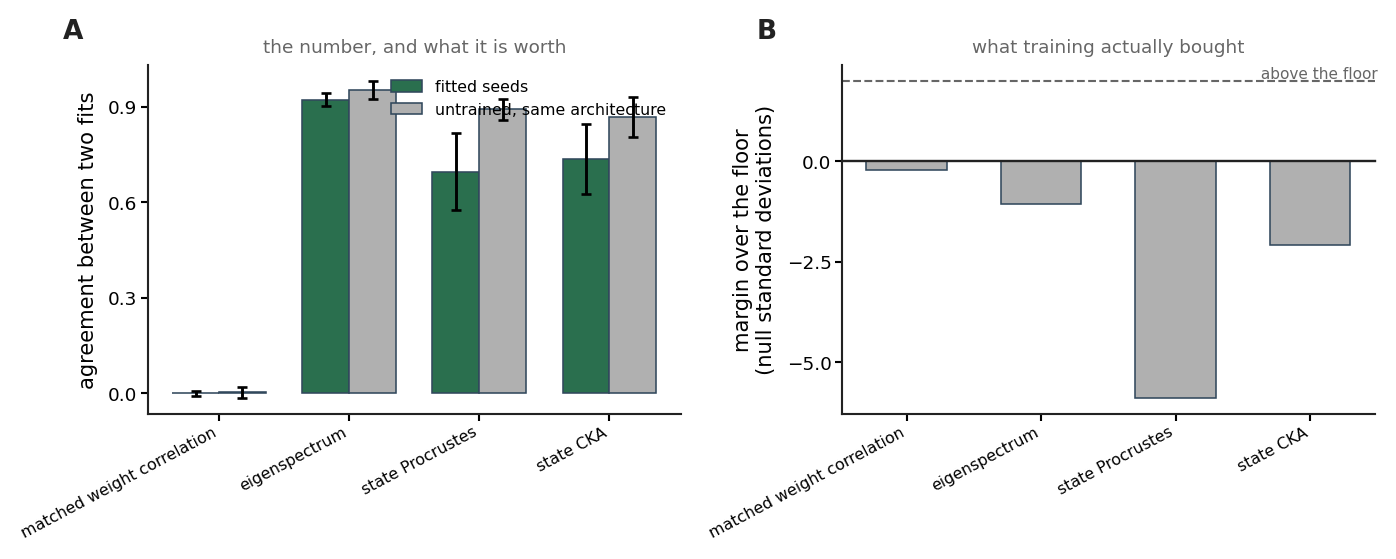

🔴 **No measure clears its architectural floor.** Independently fitted networks agree about this model no more than untrained networks of the same shape do.

This is the gate. If nothing clears the floor, fitting a hundred seeds produces a hundred copies of the same non-result, and the finding to report is that the constraints tested so far do not make the circuit identifiable — which is a real result about what this data can support, not a failure of the analysis.

In [5]:
if not histories:
    display(Markdown("Nothing to compare yet."))
else:
    fitted_dirs = list(inventory[inventory["complete"].astype(bool)]["run_dir"])
    fitted_agreement = circ.ensemble_invariants(fitted_dirs)
    architectural_null = circ.architectural_null_invariants(
        fitted_dirs[0], n_draws=ARCHITECTURE_DRAWS
    )
    comparison = circ.agreement_against_null(fitted_agreement, architectural_null)
    display(comparison.round(4))
    show(cviz.plot_agreement_against_null(comparison), "fig02_agreement_vs_null")

    cleared = comparison[comparison["margin_in_null_sd"] > 2]["measure"].tolist()
    display(Markdown(
        (f"**Measures above the floor:** {', '.join(f'`{m}`' for m in cleared)}."
         if cleared else
         "🔴 **No measure clears its architectural floor.** Independently fitted networks agree "
         "about this model no more than untrained networks of the same shape do.")
        + "\n\nThis is the gate. If nothing clears the floor, fitting a hundred seeds produces a "
        "hundred copies of the same non-result, and the finding to report is that the "
        "constraints tested so far do not make the circuit identifiable — which is a real "
        "result about what this data can support, not a failure of the analysis."
    ))

## 5. The stronger floor: fits to structureless data

The architectural null says what agreement costs nothing. It does not say what agreement
the *training process* produces on data with no structure to recover, and that is the
number the identifiability claim actually has to beat.

Two surrogates, each preserving something different and destroying the rest:

- **phase randomized** — every channel's power spectrum is preserved exactly and its
  waveform destroyed, along with the relationships between channels. Agreement that
  survives this comes from the architecture and the optimiser.
- **time shuffled** — the instantaneous population covariance is preserved exactly, and
  only the order in which states are visited is destroyed. Agreement that survives this
  comes from the geometry rather than from the dynamics.

Every seed in an arm sees the same surrogate, so the arm measures seed-to-seed variability
and not surrogate-to-surrogate variability.

,label,n_seeds,n_converged,worst_late_spikes,worst_final_over_best,median_best_loss,best_loss_spread
0,null_phase_randomized,3,3,0,1.0,0.000553,1.116511
1,null_time_shuffled,3,3,0,1.0,0.010143,1.048388


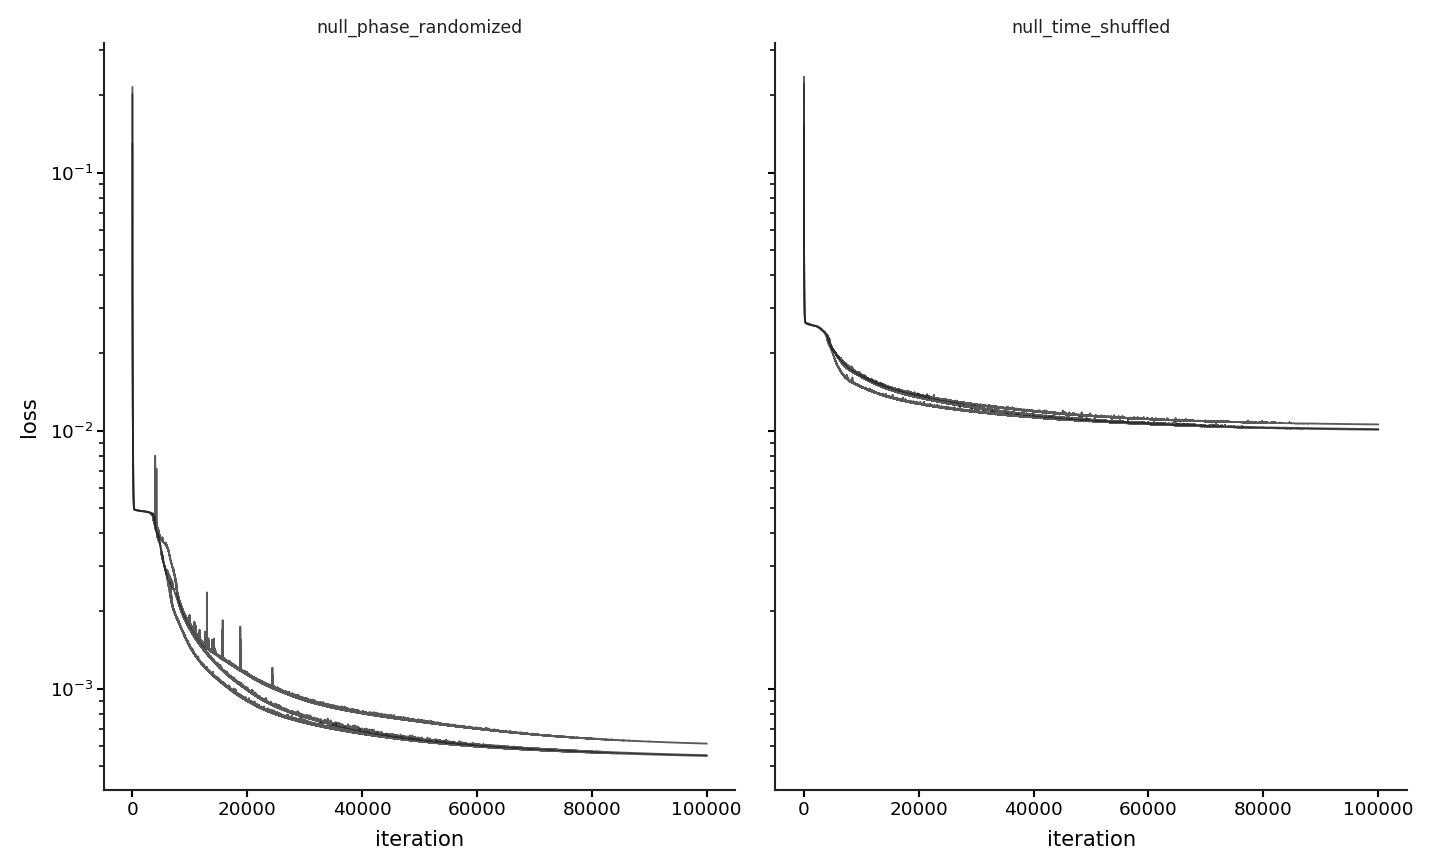

**Agreement between seeds, by what they were fitted to:**

,null_phase_randomized,null_time_shuffled,fitted
measure,,,
eigenspectrum,0.8726,0.9607,0.9215
matched weight correlation,-0.0000,-0.0017,0.0002
state CKA,0.5260,0.7994,0.7354
state Procrustes,0.5353,0.5485,0.6962


A measure whose fitted column is not clearly above both surrogate columns is not evidence that the circuit was recovered from the data — the same training procedure produces that much agreement on targets with no dynamics in them at all.

In [6]:
null_histories = sweep.load_histories(null_inventory) if len(null_inventory) else {}
if not null_histories:
    display(Markdown(
        "The surrogate arms have not been fitted yet — set `SUBMIT_NULL = True` in Section 2. "
        "Until then the architectural null in Section 4 is the only floor available, and it is "
        "the weaker of the two."
    ))
else:
    display(sweep.convergence_table(null_histories).round(6))
    show(viz.plot_sweep_loss_trajectories(null_histories), "fig03_surrogate_losses")
    rows = []
    for label, block in null_inventory[null_inventory["complete"].astype(bool)].groupby("label"):
        arm = circ.ensemble_invariants(list(block["run_dir"]))
        rows.append(arm.groupby("measure")["agreement"].mean().rename(label))
    surrogate = pd.concat(rows, axis=1)
    surrogate["fitted"] = fitted_agreement.groupby("measure")["agreement"].mean()
    display(Markdown("**Agreement between seeds, by what they were fitted to:**"))
    display(surrogate.round(4))
    display(Markdown(
        "A measure whose fitted column is not clearly above both surrogate columns is not "
        "evidence that the circuit was recovered from the data — the same training procedure "
        "produces that much agreement on targets with no dynamics in them at all."
    ))

## 6. Inter-regional communication: direction, not just magnitude

The current from region $s$ into region $t$ is $c_{s\to t}(\tau)=W[t,s]\,h_s(\tau)$. Earlier
analyses summarised it by its magnitude, which is invariant to relabelling but throws the
direction away — and the direction is where the questions live.

Two ways to recover it, both used here:

1. **Angles within one model are invariant for free.** The same signed permutation applies
   to both arguments and cancels, so no alignment step is needed. This is how the question
   *do two fixation types drive this pathway through the same channel?* gets asked directly.
2. **Push the current through the readout.** $W_{out}[t]\,c_{s\to t}$ lives in the observed
   PC space, which every fit shares by construction, so direction becomes comparable across
   seeds rather than only within one.

The split into what the readout can and cannot see is reported too, with a caveat that the
table makes visible: when a region's readout has at least as many independent rows as the
region has units, its row space *is* the whole state space and nothing can be output-null.
The split only becomes a measurement when the region is wider than the number of components
read out of it.

**How many dimensions each pathway actually uses**, pooled over seeds. This is the empirical counterpart of the rank the bottleneck imposes: a dense model that already uses three dimensions makes a rank-3 constraint a description rather than a restriction.

magnitude        potent_fraction      dimensionality  \
                          mean    std            mean  std           mean   
condition                                                                   
face_interactive         2.007  0.442             1.0  0.0          1.626   
face_non_interactive     2.530  0.457             1.0  0.0          1.947   
object                   2.434  0.422             1.0  0.0          1.912   

                             
                        std  
condition                    
face_interactive      0.308  
face_non_interactive  0.256  
object                0.222

Readout rank is **40** against **40** units per region — read the potent fraction in that light.

**Do two fixation types use the same channel?** Cosine, pooled over seeds:

mean    std    min    max
condition_a          condition_b                                     
face_interactive     face_non_interactive  0.513  0.187  0.094  0.837
                     object               -0.284  0.224 -0.663  0.230
face_non_interactive object               -0.372  0.325 -0.858  0.227

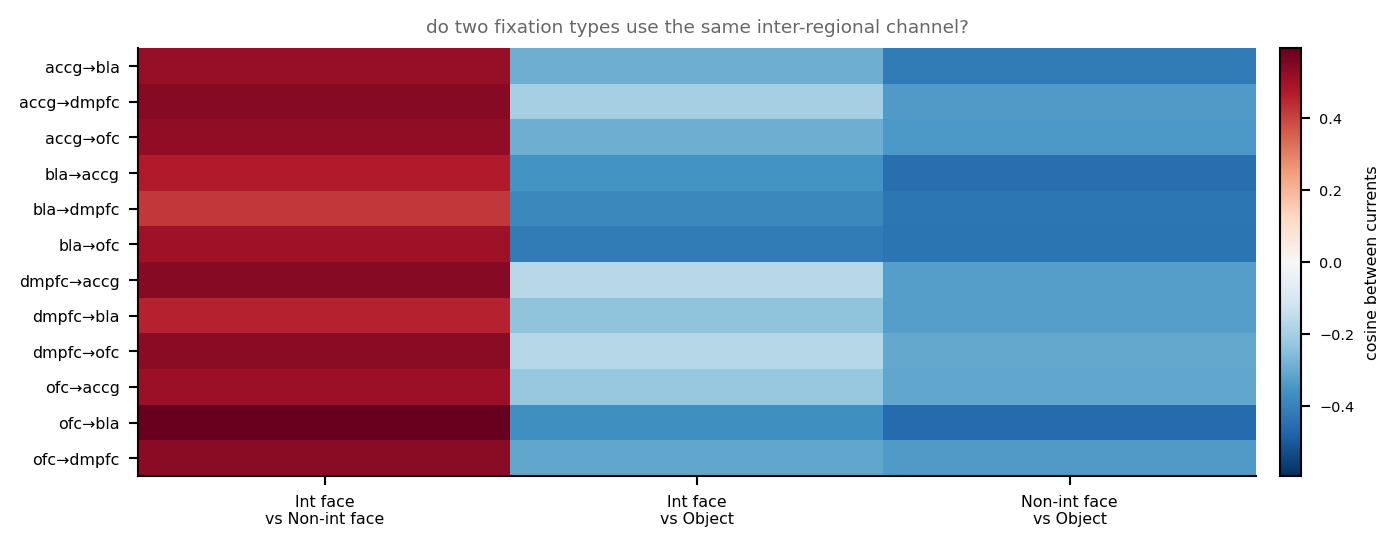

**Does incoming current push along or against the target's own dynamics?** Positive is along:

,mean,std,min,max
condition,,,,
face_interactive,0.247,0.121,-0.029,0.494
face_non_interactive,0.317,0.090,0.059,0.553
object,0.297,0.097,0.022,0.541


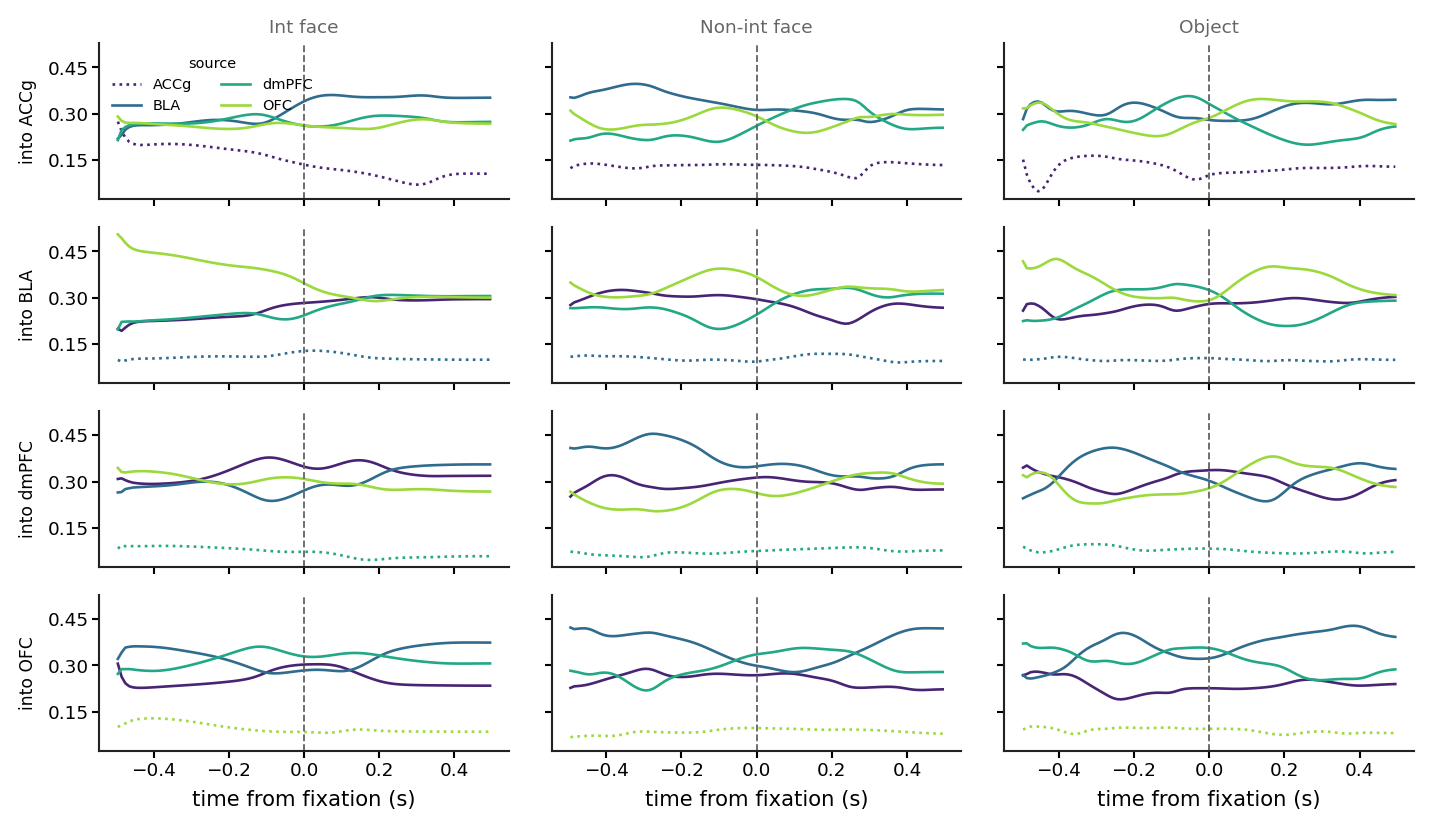

Shares rather than magnitudes, because a share is a ratio of quantities in the same space and so survives the arbitrary scaling of any one fit. Shown for one seed; the spread across seeds is what Section 4 licenses you to trust.

In [7]:
if not histories:
    display(Markdown("Nothing to read yet."))
else:
    replays = [replay_fixation_mrnn_run(Path(d)) for d in fitted_dirs]

    def across_seeds(function, value_column, index_columns):
        frames = [function(replay).assign(seed=index) for index, replay in enumerate(replays)]
        pooled = pd.concat(frames, ignore_index=True)
        return pooled.groupby(index_columns)[value_column].agg(["mean", "std"]), pooled

    potency, potency_pooled = across_seeds(
        circ.current_potency, "dimensionality", ["pathway", "condition"])
    display(Markdown(
        "**How many dimensions each pathway actually uses**, pooled over seeds. This is the "
        "empirical counterpart of the rank the bottleneck imposes: a dense model that already "
        "uses three dimensions makes a rank-3 constraint a description rather than a restriction."
    ))
    display(potency_pooled.groupby("condition")[
        ["magnitude", "potent_fraction", "dimensionality"]].agg(["mean", "std"]).round(3))
    display(Markdown(
        f"Readout rank is **{int(potency_pooled['readout_rank'].iloc[0])}** against "
        f"**{int(potency_pooled['target_units'].iloc[0])}** units per region — read the "
        f"potent fraction in that light."
    ))

    alignment = pd.concat(
        [circ.current_condition_alignment(r).assign(seed=i) for i, r in enumerate(replays)],
        ignore_index=True)
    display(Markdown("**Do two fixation types use the same channel?** Cosine, pooled over seeds:"))
    display(alignment.groupby(["condition_a", "condition_b"])["cosine"]
            .agg(["mean", "std", "min", "max"]).round(3))
    show(cviz.plot_current_condition_alignment(alignment), "fig04_condition_alignment")

    drive = pd.concat(
        [circ.current_drive_alignment(r).assign(seed=i) for i, r in enumerate(replays)],
        ignore_index=True)
    display(Markdown(
        "**Does incoming current push along or against the target's own dynamics?** "
        "Positive is along:"
    ))
    display(drive.groupby("condition")["cosine_with_intrinsic_drive"]
            .agg(["mean", "std", "min", "max"]).round(3))

    share = circ.source_share(replays[0])
    show(cviz.plot_source_share(share), "fig05_source_share")
    display(Markdown(
        "Shares rather than magnitudes, because a share is a ratio of quantities in the same "
        "space and so survives the arbitrary scaling of any one fit. Shown for one seed; the "
        "spread across seeds is what Section 4 licenses you to trust."
    ))

## 7. Three fixation types, one autonomous system

The input to this model is a **constant one-hot per condition**. The three fixation types
therefore differ only in where the trajectory starts and in a fixed offset — there is no
time-varying drive anywhere in the model. Each condition is its own autonomous dynamical
system, and every difference between fixation types is a difference in *dynamics* rather
than in input.

That makes the fixed-point structure well defined and turns an observation into a testable
claim. Interactive-face fixations carry more high-frequency power than the others and have
been the hardest condition to fit throughout this chapter. If that reflects a genuine
dynamical difference, then the local Jacobian at the interactive-face slow point should be
**less contractive**, with more modes near or above unit modulus and at higher frequency.
If instead interactive face merely has a smaller signal, the Jacobians will look alike and
the difficulty was about the objective, not the dynamics.

**Local dynamics at each condition's slow point**, across seeds:

slow_point_speed        top_modulus        n_expanding  \
                                 mean    std        mean    std        mean   
condition                                                                     
face_interactive                0.003  0.004       1.193  0.099         3.0   
face_non_interactive            0.017  0.034       0.939  0.130         0.4   
object                          0.008  0.016       1.080  0.283         1.6   

                            mean_frequency_hz         
                        std              mean    std  
condition                                             
face_interactive      1.000            25.565  0.390  
face_non_interactive  0.548            25.469  1.045  
object                2.191            25.410  0.231

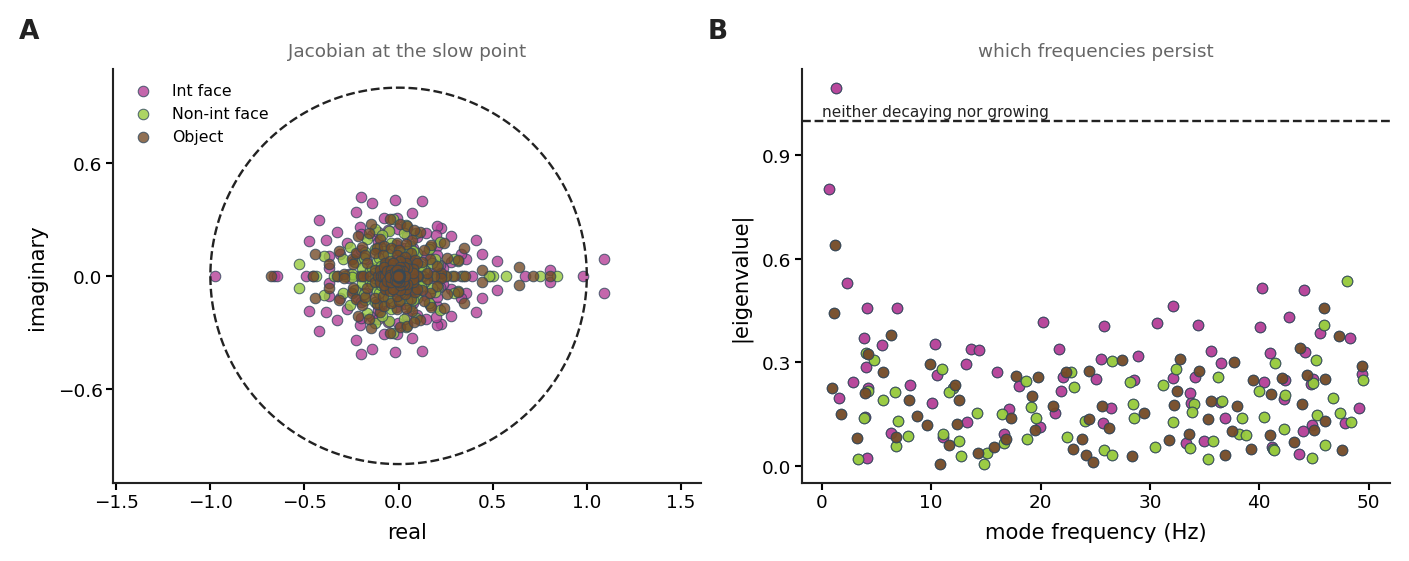

Interactive face sits at **3.0** expanding modes against **1.0** for the other conditions. A gap here means the condition that was hardest to fit is the one in the least contractive dynamical regime, which is a statement about the system rather than about the objective. No gap means the difficulty was the objective, and the balanced weighting in task 02 was the fix.

In [8]:
if not histories:
    display(Markdown("Nothing to read yet."))
else:
    rows, spectra_by_condition = [], {}
    for seed_index, replay in enumerate(replays):
        for condition_index, condition in enumerate(replay["condition_order"]):
            found = circ.slow_points(replay, condition_index, n_starts=16, iterations=600)
            slowest = int(np.argmin(found["speed"]))
            eigenvalues = circ.jacobian_eigenvalues(replay, found["points"][slowest])
            if seed_index == 0:
                spectra_by_condition[condition] = eigenvalues
            oscillating = eigenvalues[np.abs(np.imag(eigenvalues)) > 1e-9]
            rows.append({
                "seed": seed_index,
                "condition": condition,
                "slow_point_speed": float(found["speed"][slowest]),
                "top_modulus": float(np.abs(eigenvalues[0])),
                "n_expanding": int((np.abs(eigenvalues) > 1.0).sum()),
                "mean_frequency_hz": float(np.mean(
                    circ.jacobian_frequencies(oscillating, bin_size_s=BIN_SIZE_S)
                )) if len(oscillating) else np.nan,
            })
    dynamics = pd.DataFrame(rows)
    display(Markdown("**Local dynamics at each condition's slow point**, across seeds:"))
    display(dynamics.groupby("condition")[
        ["slow_point_speed", "top_modulus", "n_expanding", "mean_frequency_hz"]
    ].agg(["mean", "std"]).round(3))
    show(cviz.plot_jacobian_spectra(spectra_by_condition, bin_size_s=BIN_SIZE_S),
         "fig06_jacobian_spectra")

    expanding = dynamics.groupby("condition")["n_expanding"].mean()
    if "face_interactive" in expanding.index:
        others = expanding.drop("face_interactive").mean()
        display(Markdown(
            f"Interactive face sits at **{expanding['face_interactive']:.1f}** expanding modes "
            f"against **{others:.1f}** for the other conditions. A gap here means the condition "
            f"that was hardest to fit is the one in the least contractive dynamical regime, which "
            f"is a statement about the system rather than about the objective. No gap means the "
            f"difficulty was the objective, and the balanced weighting in task 02 was the fix."
        ))

## 8. What each pathway was carrying

Task 03 asked whether the data can be reproduced *without* a connection, by refitting from
scratch without it. This asks a different question of the fitted model: silence one pathway
in a network that has already converged, let nothing re-adapt, and see what breaks.

The two questions have different answers and the pair is more informative than either
alone. A pathway that a refit can do without, but whose removal wrecks the fitted solution,
was carrying something the model chose to route through it — a statement about the solution
found rather than about what the data requires.

**Read the ordering, not the magnitude.** Post-hoc lesion damage is partly a statement
about how finely the readout was tuned to the intact dynamics, which is why the legacy
analysis's "$R^2$ from 0.998 to $-2$ for every block" said nothing. Within one lesion the
readout tuning is shared across conditions, so the comparison *between conditions* is
meaningful even though the absolute size is not.

In [9]:
if not histories:
    display(Markdown("Nothing to read yet."))
else:
    ablation = pd.concat(
        [circ.pathway_ablation_effect(d).assign(seed=i) for i, d in enumerate(fitted_dirs)],
        ignore_index=True)
    own = ablation[ablation["region"] == ablation["target"]]
    display(Markdown("**Damage to the target region when its incoming pathway is silenced:**"))
    display(own.pivot_table(index="pathway", columns="condition", values="damage",
                            aggfunc="mean").round(2))
    by_condition = own.groupby("condition")["damage"].agg(["mean", "std"]).round(2)
    display(Markdown("Pooled over pathways and seeds:"))
    display(by_condition)
    ablation.to_csv(TASK_ROOT / "pathway_ablation.csv", index=False)
    display(Markdown(
        "Compare this with task 03's refit result directly. If interactive face is the *least* "
        "damaged by refitting without a connection and the *most* damaged by losing it after the "
        "fact, then interactive-face structure is not carried by any particular pathway — it is "
        "distributed across the network, and the fitted solution leans on all of it at once. "
        "That is a dynamical-systems claim about interactive faces that neither the data nor a "
        "single fitted model could support on its own."
    ))

**Damage to the target region when its incoming pathway is silenced:**

condition,face_interactive,face_non_interactive,object
pathway,,,
accg→bla,14.77,8.07,9.59
accg→dmpfc,21.62,9.11,8.98
accg→ofc,10.84,7.54,4.98
bla→accg,32.50,14.03,13.57
bla→dmpfc,16.63,9.15,9.53
bla→ofc,13.77,14.60,7.79
dmpfc→accg,19.06,11.21,9.33
dmpfc→bla,10.01,5.49,4.48
dmpfc→ofc,9.80,7.84,6.98


Pooled over pathways and seeds:

,mean,std
condition,,
face_interactive,16.25,11.05
face_non_interactive,9.55,4.77
object,8.54,3.92


Compare this with task 03's refit result directly. If interactive face is the *least* damaged by refitting without a connection and the *most* damaged by losing it after the fact, then interactive-face structure is not carried by any particular pathway — it is distributed across the network, and the fitted solution leans on all of it at once. That is a dynamical-systems claim about interactive faces that neither the data nor a single fitted model could support on its own.

## 9. Reading the result

Three things have to be stated together, and in this order.

**Does the ensemble fit?** If it does not clear the noise ceiling on every condition,
nothing below it is interpretable, and the constraint selected in task 04 was too tight.

**Does agreement clear its floor?** Not "is agreement high" — most of these measures are
high between networks that were never trained. The number that matters is the margin over
the architectural null, and over the stronger surrogate-target floor where that arm has been
fitted. If no measure clears both, the honest result is that the circuit is not identifiable
under the constraints tested, and the chapter reports that rather than reporting currents
whose direction changes with the seed.

**What survives is what can be claimed.** Every circuit statement in Sections 6–8 is
reported with its spread across seeds, so a property that varies between fits is visible as
such rather than presented as a finding. A measure that clears its floor licenses the
corresponding claim; one that does not, does not.

**Scaling up.** Section 4 is the gate on fitting a larger ensemble. If the small ensemble
agrees above its floor, more seeds sharpen the estimate and are worth the cluster time. If
it does not, more seeds sharpen an estimate of zero.